<a href="https://colab.research.google.com/github/ReemaSaif/Machine-Learning-Project-SDAIA/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bike Sharing Model

**The Goal:**

To predict how many bikes will be rented per hour (cnt) given weather and seasonal conditions, so the bike‑sharing company can better plan bikes allocation, staffing, and maintenance.

**Machine Learning Task:**

* Type: Supervised Learning
* Task: Regression
* Description: Using the available features in the dataset, the model predicts the number of bikes that will be rented during a specific hour of the day.
* Input features: season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed
* Target Variable: cnt 	(count of total rental bikes = casual + registered)



First we need to import all the required libraries:



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Then we need to load the dataset:

In [2]:
bike = pd.read_csv("bike sharing.csv")

In [3]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## **Data Validation & Cleaning:**

In [4]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
bike.shape

(17379, 17)

In [6]:
bike.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [7]:
bike.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [8]:
bike.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [9]:
bike.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
bike.duplicated().sum()

np.int64(0)

In [11]:
bike = bike.drop(columns = ['instant' , 'dteday' , 'casual' , 'registered'])

In [12]:
bike.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [13]:
bike.rename(columns={'yr':'year',
                     'mnth':'month',
                     'hr':'hour',
                     'weathersit':'weather_situation',
                     'temp': 'temperature',
                     'atemp': 'feels_like_temp',
                     'hum':'humidity',
                     'cnt':'total_count'}, inplace=True)

In [14]:
bike.head()

,season,year,month,hour,holiday,weekday,workingday,weather_situation,temperature,feels_like_temp,humidity,windspeed,total_count
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [15]:
catgory_column = ['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather_situation']
for c in catgory_column:
    bike[c] = bike[c].astype('category')

In [16]:
bike.dtypes

,0
season,category
year,category
month,category
hour,category
holiday,category
weekday,category
workingday,category
weather_situation,category
temperature,float64
feels_like_temp,float64


## **Exploratory Data Analysis (EDA):**

**Hourly Demand Pattern:**

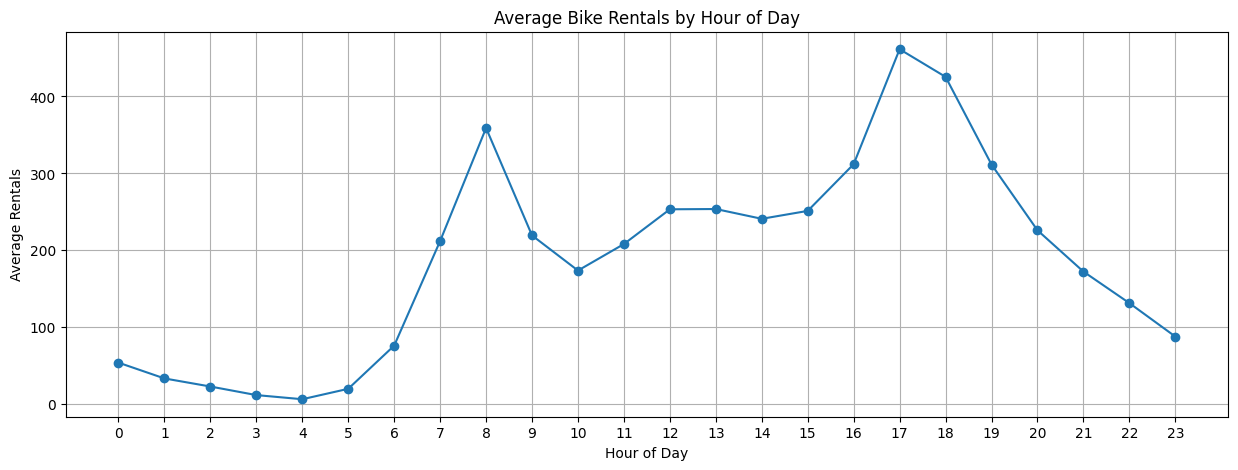

In [17]:
hourly_avg = bike.groupby("hour", observed=False)["total_count"].mean()
plt.figure(figsize=(15,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title("Average Bike Rentals by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.xticks(range(0,24))
plt.show()


* From this graph, we see that bike‑rental rush hours occur around 8 AM and 5 PM.

**Weather Condition Distribution:**

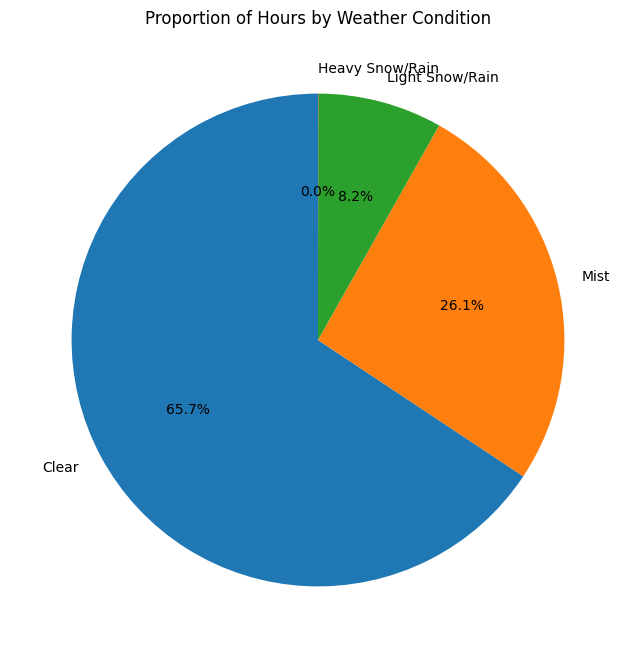

In [18]:
weather_counts = bike['weather_situation'].value_counts().sort_index()
labels = {1: "Clear", 2: "Mist", 3: "Light Snow/Rain", 4: "Heavy Snow/Rain"}

plt.figure(figsize=(15,8))
plt.pie(
    weather_counts,
    labels=[labels[i] for i in weather_counts.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proportion of Hours by Weather Condition')
plt.show()

* From the pie chart we see that clear and misty weather dominate the dataset, making up more than 90% of all recorded hours.  Light Snow/Rain represents 8.2% of the hours, while Heavy Snow/Rain is nonexistent (0.0%), indicating that severe weather rarely occurred during the recorded period. .


**Correlation Heatmap of Numerical Features:**

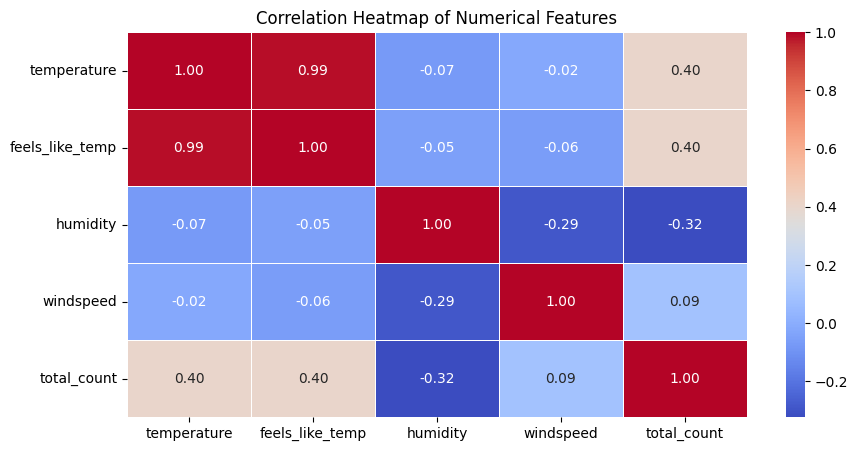

In [19]:
correlation = bike.corr(numeric_only=True)
plt.figure(figsize=(10, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

* From the heatmap we see that temperature and feels‑like temperature are highly positively correlated (0.99), and both show a moderate positive correlation (0.40) with total_count, indicating that bike rentals increase as the weather becomes warmer. Humidity has a moderate negative correlation (-0.32) with total_count, meaning that higher humidity is associated with fewer rentals. Windspeed shows a weak positive correlation (0.09) with total_count, meaning it has little influence on rental demand. Overall, the temperature variables show the strongest positive relationships with the target, while humidity shows the strongest negative effect.


**Hourly Bike Rentals by Working Day vs Weekend:**

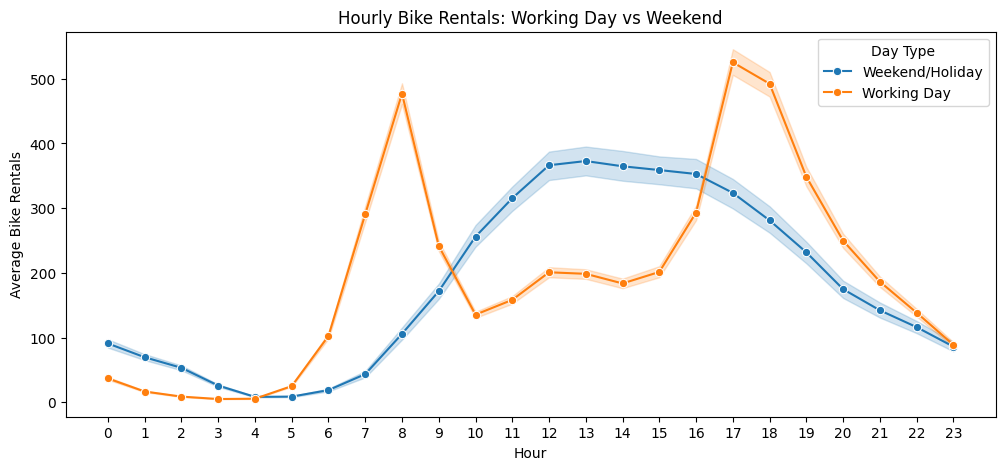

In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=bike, x='hour', y='total_count', hue=bike['workingday'].map({0: 'Weekend/Holiday', 1: 'Working Day'}), marker='o')
plt.title("Hourly Bike Rentals: Working Day vs Weekend")
plt.xlabel("Hour")
plt.ylabel("Average Bike Rentals")
plt.legend(title='Day Type')
plt.xticks(range(0, 24))
plt.show()

* From the plot, we see two distinct rental patterns. On working days, bike rentals peak sharply around 8 AM and 5 PM. In contrast, weekends and holidays show a smoother pattern, with rentals peaking around midday (12–4 PM) and then declining steadily throughout the evening. Overall, this means that weekday usage reflects work‑related travel, while weekend usage reflects more flexible, leisure‑based riding.

**Average Bike Demand by Season:**

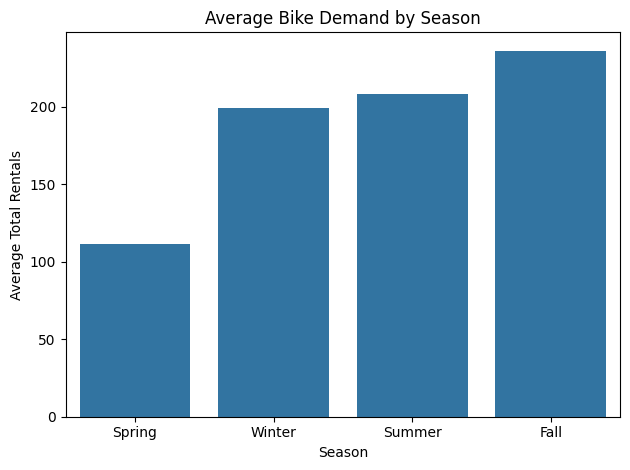

In [21]:
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}

season_average = bike.groupby('season', observed=False)['total_count'].mean().reset_index()

season_average['season_label'] = season_average['season'].map(season_labels)

order = season_average.sort_values("total_count")["season_label"]

sns.barplot(data=season_average, x='season_label', y='total_count',order=order, hue_order=order)
plt.title("Average Bike Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Total Rentals")
plt.tight_layout()
plt.show()

From the bar plot Fall shows the highest average bike demand, indicating that riders are most active during this season. In contrast, Spring has the lowest demand, likely due to transitional weather conditions. Overall, the results suggest that seasonal weather patterns play a significant role in shaping rider behavior.

## **Feature Engineering:**

I chose these feature engneering:

1. is_weekend: 1 if Saturday (6) or Sunday (0), else 0
2. is_rush_hour: 1 if 7-9 AM or  16-19 PM, else 0
3. season_peak: 1 if season == 3 (fall), else 0
4. temperature_bin:
     * cold: temp < 0.3
     * mild: 0.3 ≤ temp ≤ 0.6
     * hot: temp > 0.6

**is_weekend:**

In [22]:
bike["is_weekend"] = bike["weekday"].isin([0, 6]).astype(int)

**is_rush_hour:**

In [23]:
rush_hours = [7, 8, 9, 16, 17, 18, 19]
bike["is_rush_hour"] = bike["hour"].isin(rush_hours).astype(int)

**season_peak:**

In [24]:
bike["season_peak"] = (bike["season"] == 3).astype(int)

**temperature_bin:**

In [25]:
bike['temperature_bin'] = pd.cut(bike['temperature'], bins=[0, 0.3, 0.6, 1], labels=['cold', 'mild', 'hot'], ordered=True)

In [26]:
bike.head()

,season,year,month,hour,holiday,weekday,workingday,weather_situation,temperature,feels_like_temp,humidity,windspeed,total_count,is_weekend,is_rush_hour,season_peak,temperature_bin
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,0,0,cold
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,0,0,cold
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,0,0,cold
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,0,0,cold
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,0,0,cold


## **Data Split:**

Train/Test Split:

In [27]:
# Split by year to avoid data leakage

train_data = bike[bike['year'] == 0]   # 2011
test_data  = bike[bike['year'] == 1]   # 2012

Assign Features (X) and Target (y):

In [28]:
X_train = train_data.drop(columns=['total_count'])
y_train = train_data['total_count']

X_test = test_data.drop(columns=['total_count'])
y_test = test_data['total_count']

print("X_train is:", X_train.shape)
print("y_train is:", y_train.shape)
print("X_test is:", X_test.shape)
print("y_test is:", y_test.shape)

X_train is: (8645, 16)
y_train is: (8645,)
X_test is: (8734, 16)
y_test is: (8734,)


## **Encoding Categorical Features (OneHotEncoder):**

In [29]:
catgory_feature = ['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather_situation' , 'temperature_bin']

oneHot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', oneHot_encoder, catgory_feature)
    ],
    remainder='passthrough' # Keeps numerical columns unchanged
)

* NOTE: To check if OneHotEncoding is correct,see the output shape if (Same number of rows as X_train , More columns than before) it means is correct. Otherwise is wrong.


In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
print(X_train_processed.shape)

(8645, 66)


## **Train Models:**

### **Model 1: Linear Regression**

**Build the pipeline:**

In [32]:
linear_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
] )

**Train the model:**

In [33]:
linear_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['season', 'year', 'month',
                                                   'hour', 'holiday', 'weekday',
                                                   'workingday',
                                                   'weather_situation',
                                                   'temperature_bin'])])),
                ('model', LinearRegression())])

**Predict:**

In [34]:
linear_y_pred = linear_pipeline.predict(X_test)

**Evaluate:**

In [35]:
RMSE_linear = np.sqrt(mean_squared_error(y_test, linear_y_pred))
MAE_linear = mean_absolute_error(y_test, linear_y_pred)
R2_linear = r2_score(y_test, linear_y_pred)

print("Linear Regression Results")
print("RMSE:", RMSE_linear)
print("MAE:", MAE_linear)
print("R²:", R2_linear)

Linear Regression Results
RMSE: 158.17186334970893
MAE: 110.55018891303938
R²: 0.42669488216790097


### **Model 2: Random Forest Regressor**

**Build the pipeline:**

In [36]:
randomforest_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators = 200, random_state = 42))
] )

**Train the model:**

In [37]:
randomforest_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['season', 'year', 'month',
                                                   'hour', 'holiday', 'weekday',
                                                   'workingday',
                                                   'weather_situation',
                                                   'temperature_bin'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

**Predict:**

In [38]:
randomforest_y_pred = randomforest_pipeline.predict(X_test)

**Evaluate:**

In [39]:
RMSE_randomforest = np.sqrt(mean_squared_error(y_test, randomforest_y_pred))
MAE_randomforest = mean_absolute_error(y_test, randomforest_y_pred)
R2_randomforest = r2_score(y_test, randomforest_y_pred)

print("Random Forest Results")
print("RMSE:", RMSE_randomforest)
print("MAE:", MAE_randomforest)
print("R²:", R2_randomforest)

Random Forest Results
RMSE: 126.1649358128182
MAE: 90.30408261228698
R²: 0.635242106385866


## **Evaluate Models:**

**Compare between models metrices:**

In [40]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [RMSE_linear, RMSE_randomforest],
    "MAE": [MAE_linear, MAE_randomforest],
    "R²": [R2_linear, R2_randomforest]
})

results = results.round(2)
results

,Model,RMSE,MAE,R²
0,Linear Regression,158.17,110.55,0.43
1,Random Forest Regressor,126.16,90.30,0.64


Random Forest clearly outperforms Linear Regression because:

* Lower RMSE (126 vs 158): Random Forest makes smaller prediction errors.
* Lower MAE (90 vs 110): On average, Random Forest is 20 units more accurate. [110-90=20]
* Higher R² (0.64 vs 0.43): Random Forest explains 64% of the variance, while Linear Regression explains only 43%.


Random Forest performs better in this project because it can capture non-linear patterns in the bike rental data, whereas Linear Regression cannot. As a result, Random Forest delivers more accurate and reliable predictions, making it the preferred model for deployment.

**Feature importance (Random Forest):**

In [41]:
ohe = randomforest_pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(catgory_feature)

numeric_features = [c for c in X_train.columns if c not in catgory_feature]

all_features = np.concatenate([ohe_features, numeric_features])

important = randomforest_pipeline.named_steps['model'].feature_importances_

In [42]:
# Create a table showing each feature and its importance score

feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance Score': important
}).sort_values(by='Importance Score', ascending=False)

feature_importance.head(5)

,Feature,Importance Score
64,is_rush_hour,0.246526
60,feels_like_temp,0.152052
59,temperature,0.087333
61,humidity,0.078579
50,workingday_0,0.035125


**Top 5 Most Important Features (Random Forest Model):**

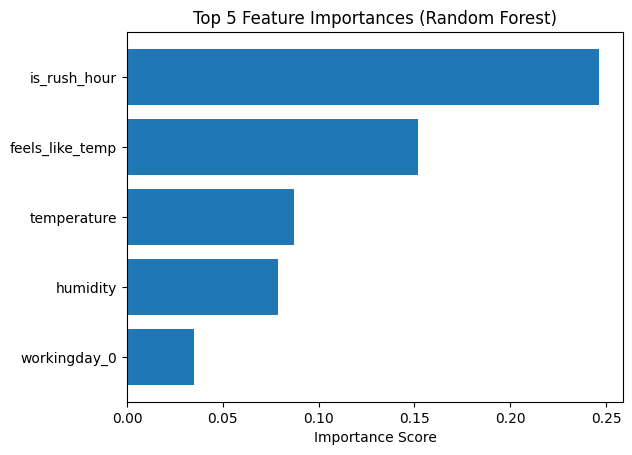

In [43]:
plt.barh(feature_importance.head(5)['Feature'], feature_importance.head(5)['Importance Score'])
plt.gca().invert_yaxis()
plt.title("Top 5 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

The feature importance ranking indicates that **is_rush_hour** has the biggest impact on the model’s prediction outcome. This confirms that commuting patterns during rush hours are the dominant drivers of bike‑rental demand, outweighing the effects of weather and calendar‑based features.


### **Residual Plot:**

In [44]:
randomforest_y_pred = randomforest_pipeline.predict(X_test)
residuals = y_test - randomforest_y_pred

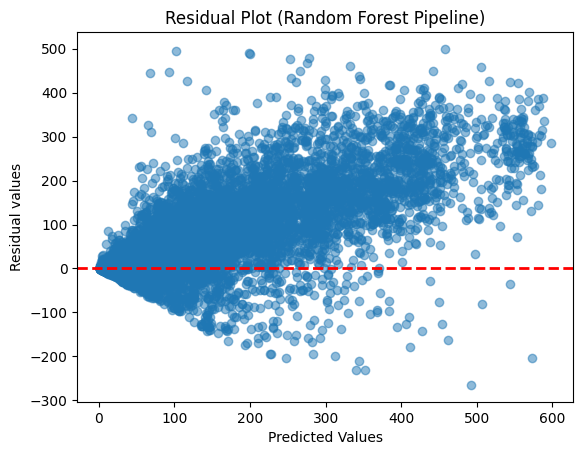

In [45]:
plt.scatter(randomforest_y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residual values")
plt.title("Residual Plot (Random Forest Pipeline)")
plt.show()

 The residual plot shows that the Random Forest model performs well overall, with residuals randomly scattered around zero indicating no major bias. However, the residuals become more spread out at higher predicted values indicating that the model is less accurate during high‑demand periods.

## **Deploy:**

Since Random Forest Regressor Model performed better, i chose to deploy it:

In [46]:
import joblib
joblib.dump(randomforest_pipeline, "randomforest_model.pkl")

['randomforest_model.pkl']